In [1]:
import json
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l1, l2
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, Callback

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils import class_weight
import seaborn as s

In [2]:
X_train = pd.read_csv("train.csv")
X_val = pd.read_csv("val.csv")
X_test = pd.read_csv("test.csv")

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (4924, 12)
Validation shape: (1055, 12)
Test shape: (1056, 12)


In [3]:
y_train = np.load("y_train.npy")
y_val = np.load("y_val.npy")
y_test = np.load("y_test.npy")

print(f"Train shape: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")
print(f"Label shape: {y_train.shape}, {y_val.shape}, {y_test.shape}")

Train shape: (4924, 12), Validation: (1055, 12), Test: (1056, 12)
Label shape: (4924, 7), (1055, 7), (1056, 7)


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Determine input and output dimensions
input_dim = X_train.shape[1]    # 11 features
output_dim = y_train.shape[1]   # number of classes (7)

# ============================
# BUILD MODEL
# ============================
model = Sequential()
model.add(Dense(96, activation='relu', input_shape=(input_dim,)))
model.add(Dense(96, activation='relu'))
model.add(Dense(output_dim, activation='softmax'))


# === Compile ===
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint = ModelCheckpoint('model_1.h5', monitor='val_accuracy', save_best_only=True)

model.summary()


c:\Users\aaaxx\miniconda3\envs\AttendanceSystem33\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 96)             │         1,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 96)             │         9,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           679 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,239 (43.90 KB)

 Trainable params: 11,239 (43.90 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=100,
                    batch_size=32,
                    callbacks=[early_stop, checkpoint])


Epoch 1/100
138/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3355 - loss: 1.6927

154/154 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3454 - loss: 1.6715 - val_accuracy: 0.4948 - val_loss: 1.2617
Epoch 2/100
138/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5217 - loss: 1.2051

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5244 - loss: 1.1993 - val_accuracy: 0.5536 - val_loss: 1.1134
Epoch 3/100
143/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5923 - loss: 1.0537

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5921 - loss: 1.0529 - val_accuracy: 0.5782 - val_loss: 1.0494
Epoch 4/100
130/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6075 - loss: 0.9961

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6074 - loss: 0.9923 - val_accuracy: 0.5905 - val_loss: 0.9909
Epoch 5/100
134/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6218 - loss: 0.9385

...

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8581 - loss: 0.3867 - val_accuracy: 0.7697 - val_loss: 0.6188
Epoch 52/100
141/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8629 - loss: 0.3738

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8625 - loss: 0.3746 - val_accuracy: 0.7754 - val_loss: 0.6021
Epoch 53/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8589 - loss: 0.3781 - val_accuracy: 0.7611 - val_loss: 0.6166
Epoch 54/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8645 - loss: 0.3610 - val_accuracy: 0.7744 - val_loss: 0.5944
Epoch 55/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8720 - loss: 0.3457 - val_accuracy: 0.7583 - val_loss: 0.6126
Epoch 56/100
147/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8625 - loss: 0.3668

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8627 - loss: 0.3663 - val_accuracy: 0.7782 - val_loss: 0.6099
Epoch 57/100
151/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8745 - loss: 0.3398

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8742 - loss: 0.3403 - val_accuracy: 0.7801 - val_loss: 0.6046
Epoch 58/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8762 - loss: 0.3384 - val_accuracy: 0.7526 - val_loss: 0.6560
Epoch 59/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8657 - loss: 0.3483 - val_accuracy: 0.7763 - val_loss: 0.6172
Epoch 60/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8696 - loss: 0.3467 - val_accuracy: 0.7659 - val_loss: 0.6237
Epoch 61/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8705 - loss: 0.3270 - val_accuracy: 0.7791 - val_loss: 0.5937
Epoch 62/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8886 - loss: 0.3179 - val_accuracy: 0.7725 - val_loss: 0.6176
Epoch 63/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8851 - loss: 0.3172 - val_accuracy: 0.7801 - val_loss: 0.6125
Epoch 64/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8721 - loss: 0.3307 - val_accuracy:

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8801 - loss: 0.3235 - val_accuracy: 0.7820 - val_loss: 0.6043
Epoch 66/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8870 - loss: 0.3012 - val_accuracy: 0.7687 - val_loss: 0.6125
Epoch 67/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8944 - loss: 0.3105 - val_accuracy: 0.7545 - val_loss: 0.6811
Epoch 68/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8839 - loss: 0.3072 - val_accuracy: 0.7754 - val_loss: 0.6254
Epoch 69/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8825 - loss: 0.3092 - val_accuracy: 0.7801 - val_loss: 0.5992
Epoch 70/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8930 - loss: 0.2989 - val_accuracy: 0.7782 - val_loss: 0.6297
Epoch 71/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8949 - loss: 0.3006 - val_accuracy: 0.7697 - val_loss: 0.6529


In [6]:
# === Save training history ===
with open("training_history_model1.json", "w") as f:
    json.dump(history.history, f)


In [7]:
# === Evaluate ===
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)



33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7852 - loss: 0.6442
Test Accuracy: 0.7907
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


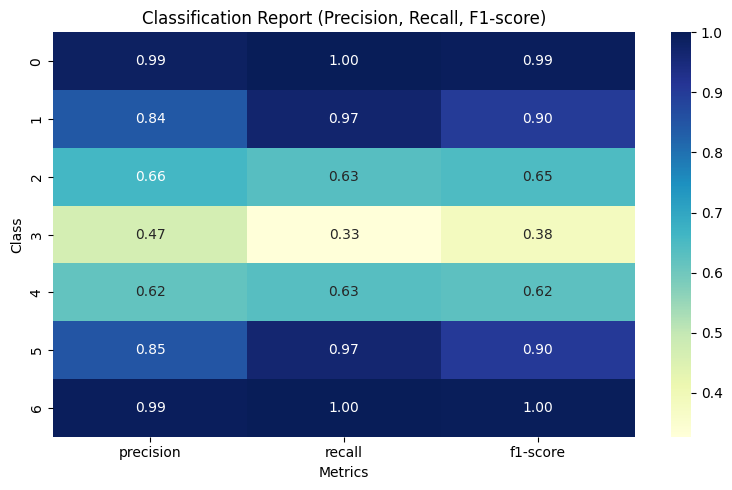

In [8]:
from sklearn.metrics import classification_report
import seaborn as sns
import pandas as pd

# === Classification Report as DataFrame ===
report_dict = classification_report(y_true, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

# Remove 'accuracy', 'macro avg', and 'weighted avg' rows (optional)
metrics_df = report_df.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')

# === Visualize as Heatmap ===
plt.figure(figsize=(8, 5))
sns.heatmap(metrics_df.iloc[:, :3], annot=True, cmap='YlGnBu', fmt=".2f")
plt.title("Classification Report (Precision, Recall, F1-score)")
plt.ylabel("Class")
plt.xlabel("Metrics")
plt.tight_layout()
plt.show()


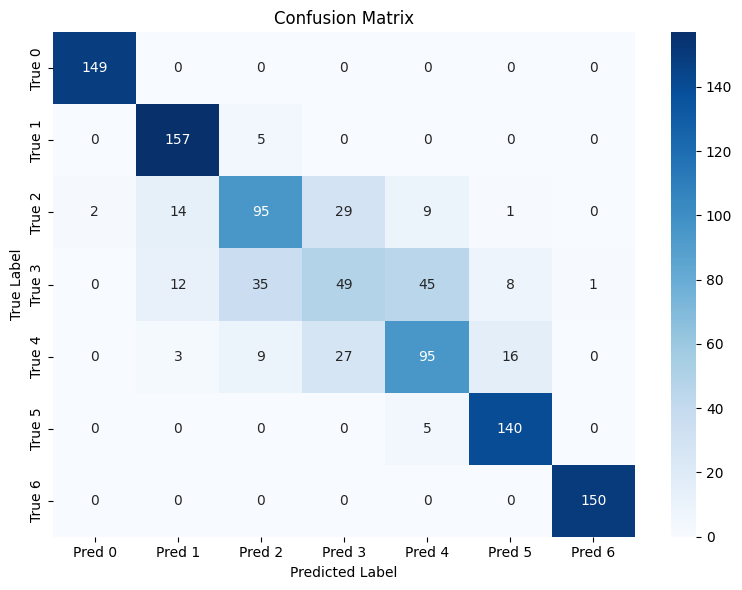

In [9]:
import seaborn as sns

# === Confusion Matrix ===
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f"Pred {i}" for i in range(y_train.shape[1])],
            yticklabels=[f"True {i}" for i in range(y_train.shape[1])])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


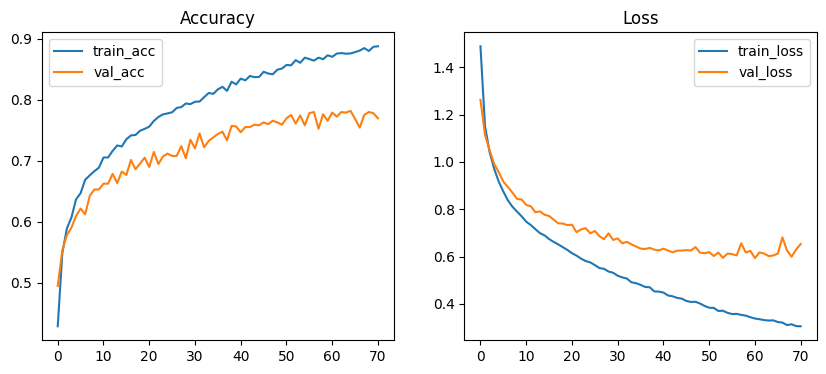

In [10]:
# === Plot training ===
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend(); plt.title('Accuracy')
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend(); plt.title('Loss')
plt.savefig("model1_training_curves.png")
plt.show()

In [11]:
# === Model Architecture ===
model2 = Sequential()
model2.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model2.add(BatchNormalization())
model2.add(Dropout(0.3))
model2.add(Dense(96, activation='relu'))
model2.add(BatchNormalization())
model2.add(Dropout(0.3))
model2.add(Dense(64, activation='relu'))
model2.add(Dense(y_train.shape[1], activation='softmax'))


c:\Users\aaaxx\miniconda3\envs\AttendanceSystem33\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:

# === Compile ===
model2.compile(optimizer=RMSprop(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [13]:
# === Callbacks ===
early_stop = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)
checkpoint = ModelCheckpoint('model_2.h5', monitor='val_accuracy', save_best_only=True)
lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

In [14]:
# === Train ===
history = model2.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=120,
                    batch_size=32,
                    callbacks=[early_stop, checkpoint, lr_schedule])


Epoch 1/120
128/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2957 - loss: 1.8810

154/154 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3095 - loss: 1.8389 - val_accuracy: 0.5280 - val_loss: 1.4068 - learning_rate: 0.0010
Epoch 2/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4699 - loss: 1.3505

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4700 - loss: 1.3501 - val_accuracy: 0.5621 - val_loss: 1.1265 - learning_rate: 0.0010
Epoch 3/120
141/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5351 - loss: 1.1622

154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5335 - loss: 1.1645 - val_accuracy: 0.5867 - val_loss: 1.0409 - learning_rate: 0.0010
Epoch 4/120
117/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5306 - loss: 1.1478

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5317 - loss: 1.1445 - val_accuracy: 0.6095 - val_loss: 0.9712 - learning_rate: 0.0010
Epoch 5/120
141/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5478 - loss: 1.1165

...

154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7393 - loss: 0.6492 - val_accuracy: 0.7441 - val_loss: 0.6517 - learning_rate: 5.0000e-04
Epoch 67/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7403 - loss: 0.6430 - val_accuracy: 0.7374 - val_loss: 0.6467 - learning_rate: 5.0000e-04
Epoch 68/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7460 - loss: 0.6514 - val_accuracy: 0.7374 - val_loss: 0.6453 - learning_rate: 5.0000e-04
Epoch 69/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7285 - loss: 0.6688 - val_accuracy: 0.7365 - val_loss: 0.6497 - learning_rate: 5.0000e-04
Epoch 70/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7427 - loss: 0.6497 - val_accuracy: 0.7403 - val_loss: 0.6377 - learning_rate: 5.0000e-04
Epoch 71/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7421 - loss: 0.6305 - val_accuracy: 0.7431 - val_loss: 0.6395 - learning_rate: 5.0000e-04
Epoch 72/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy:

154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7362 - loss: 0.6549 - val_accuracy: 0.7460 - val_loss: 0.6296 - learning_rate: 5.0000e-04
Epoch 75/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7378 - loss: 0.6369 - val_accuracy: 0.7450 - val_loss: 0.6235 - learning_rate: 5.0000e-04
Epoch 76/120
133/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7438 - loss: 0.6375

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7430 - loss: 0.6387 - val_accuracy: 0.7526 - val_loss: 0.6209 - learning_rate: 5.0000e-04
Epoch 77/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7615 - loss: 0.6040 - val_accuracy: 0.7460 - val_loss: 0.6197 - learning_rate: 5.0000e-04
Epoch 78/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7566 - loss: 0.6297 - val_accuracy: 0.7441 - val_loss: 0.6397 - learning_rate: 5.0000e-04
Epoch 79/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7322 - loss: 0.6678 - val_accuracy: 0.7507 - val_loss: 0.6285 - learning_rate: 5.0000e-04
Epoch 80/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7369 - loss: 0.6393 - val_accuracy: 0.7441 - val_loss: 0.6224 - learning_rate: 5.0000e-04
Epoch 81/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7525 - loss: 0.6274 - val_accuracy: 0.7441 - val_loss: 0.6220 - learning_rate: 5.0000e-04
Epoch 82/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy:

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7551 - loss: 0.6360 - val_accuracy: 0.7545 - val_loss: 0.6119 - learning_rate: 2.5000e-04
Epoch 89/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7468 - loss: 0.6300 - val_accuracy: 0.7545 - val_loss: 0.6190 - learning_rate: 2.5000e-04
Epoch 90/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7466 - loss: 0.6308 - val_accuracy: 0.7526 - val_loss: 0.6139 - learning_rate: 2.5000e-04
Epoch 91/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7583 - loss: 0.5990 - val_accuracy: 0.7526 - val_loss: 0.6173 - learning_rate: 2.5000e-04
Epoch 92/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7471 - loss: 0.6271 - val_accuracy: 0.7479 - val_loss: 0.6195 - learning_rate: 2.5000e-04
Epoch 93/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7570 - loss: 0.5955 - val_accuracy: 0.7498 - val_loss: 0.6148 - learning_rate: 2.5000e-04
Epoch 94/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy:

154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7530 - loss: 0.5965 - val_accuracy: 0.7555 - val_loss: 0.6159 - learning_rate: 1.2500e-04
Epoch 97/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7454 - loss: 0.6194 - val_accuracy: 0.7526 - val_loss: 0.6120 - learning_rate: 1.2500e-04
Epoch 98/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7630 - loss: 0.6156 - val_accuracy: 0.7536 - val_loss: 0.6145 - learning_rate: 1.2500e-04
Epoch 99/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7399 - loss: 0.6305 - val_accuracy: 0.7545 - val_loss: 0.6144 - learning_rate: 6.2500e-05
Epoch 100/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7524 - loss: 0.6006 - val_accuracy: 0.7545 - val_loss: 0.6125 - learning_rate: 6.2500e-05


In [15]:
# === Save training history ===
with open("training_history_model2.json", "w") as f:
    json.dump(history.history, f)


In [16]:

# === Evaluate ===
test_loss, test_acc = model2.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

y_pred = np.argmax(model2.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)



33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7552 - loss: 0.6508
Test Accuracy: 0.7519
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


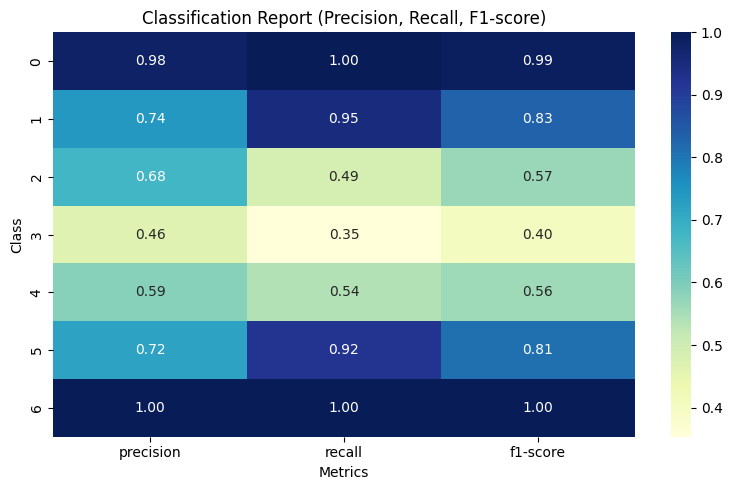

In [17]:
from sklearn.metrics import classification_report
import seaborn as sns
import pandas as pd

# === Classification Report as DataFrame ===
report_dict = classification_report(y_true, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

# Remove 'accuracy', 'macro avg', and 'weighted avg' rows (optional)
metrics_df = report_df.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')

# === Visualize as Heatmap ===
plt.figure(figsize=(8, 5))
sns.heatmap(metrics_df.iloc[:, :3], annot=True, cmap='YlGnBu', fmt=".2f")
plt.title("Classification Report (Precision, Recall, F1-score)")
plt.ylabel("Class")
plt.xlabel("Metrics")
plt.tight_layout()
plt.show()


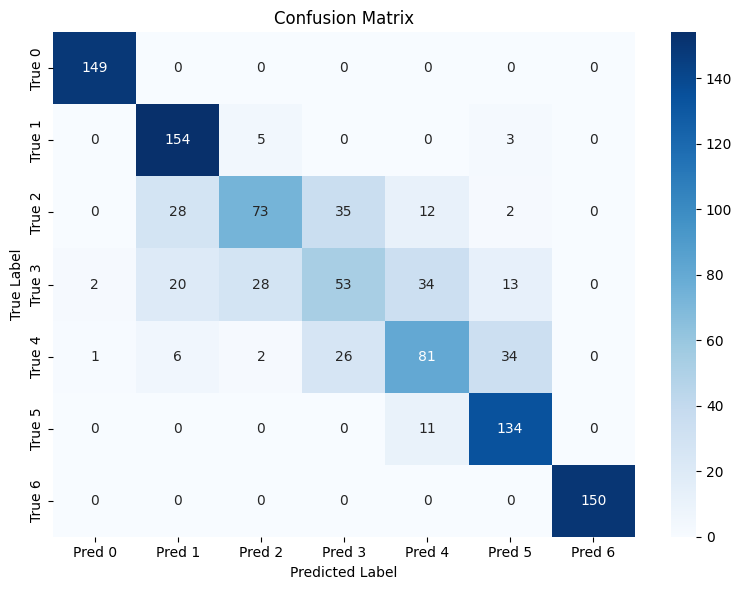

In [18]:
import seaborn as sns

# === Confusion Matrix ===
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f"Pred {i}" for i in range(y_train.shape[1])],
            yticklabels=[f"True {i}" for i in range(y_train.shape[1])])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


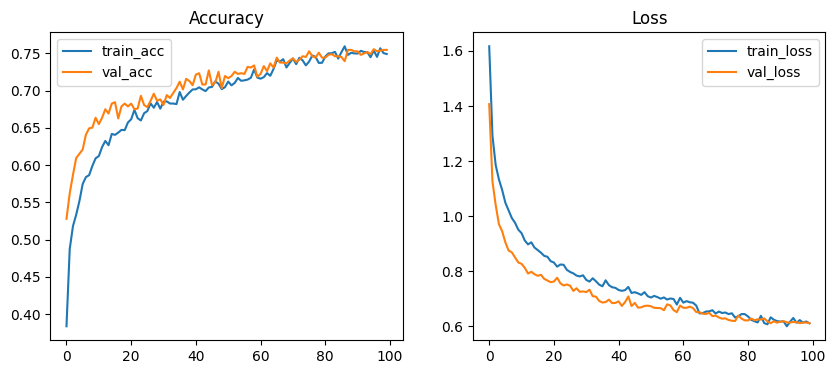

In [19]:

# === Plot training ===
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend(); plt.title('Accuracy')
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend(); plt.title('Loss')
plt.savefig("model2_training_curves.png")
plt.show()


In [20]:
# === Model Architecture ===
model3 = Sequential()
model3.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],), kernel_regularizer=l2(0.001)))
model3.add(Dropout(0.5))
model3.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
model3.add(Dropout(0.2))
model3.add(Dense(32, activation='relu'))
model3.add(Dense(y_train.shape[1], activation='softmax'))

c:\Users\aaaxx\miniconda3\envs\AttendanceSystem33\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
# === Compile ===
optimizer = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
model3.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [22]:
# === Callbacks ===
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
checkpoint = ModelCheckpoint('model_3.h5', monitor='val_accuracy', save_best_only=True)


In [23]:
# === Train ===
history = model3.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=150,
                    batch_size=64,
                    callbacks=[early_stop, checkpoint])

Epoch 1/150
59/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1764 - loss: 2.0501  

77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1918 - loss: 2.0295 - val_accuracy: 0.4047 - val_loss: 1.7237
Epoch 2/150
72/77 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3551 - loss: 1.7134

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3566 - loss: 1.7092 - val_accuracy: 0.4512 - val_loss: 1.4745
Epoch 3/150
71/77 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4285 - loss: 1.5334

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4305 - loss: 1.5293 - val_accuracy: 0.4853 - val_loss: 1.3494
Epoch 4/150
70/77 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4739 - loss: 1.4194

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4736 - loss: 1.4173 - val_accuracy: 0.4995 - val_loss: 1.2887
Epoch 5/150
75/77 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4738 - loss: 1.3706

...

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6341 - loss: 0.9694 - val_accuracy: 0.6607 - val_loss: 0.8901
Epoch 65/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6329 - loss: 0.9449 - val_accuracy: 0.6569 - val_loss: 0.8810
Epoch 66/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6302 - loss: 0.9412 - val_accuracy: 0.6588 - val_loss: 0.8763
Epoch 67/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6365 - loss: 0.9494 - val_accuracy: 0.6483 - val_loss: 0.8832
Epoch 68/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6236 - loss: 0.9525 - val_accuracy: 0.6540 - val_loss: 0.8723
Epoch 69/150
76/77 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6353 - loss: 0.9344

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6351 - loss: 0.9349 - val_accuracy: 0.6749 - val_loss: 0.8693
Epoch 70/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6379 - loss: 0.9321 - val_accuracy: 0.6493 - val_loss: 0.8821
Epoch 71/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6469 - loss: 0.9297 - val_accuracy: 0.6512 - val_loss: 0.8792
Epoch 72/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6381 - loss: 0.9425 - val_accuracy: 0.6701 - val_loss: 0.8714
Epoch 73/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6353 - loss: 0.9205 - val_accuracy: 0.6645 - val_loss: 0.8678
Epoch 74/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6281 - loss: 0.9436 - val_accuracy: 0.6711 - val_loss: 0.8680
Epoch 75/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6485 - loss: 0.9303 - val_accuracy: 0.6626 - val_loss: 0.8603
Epoch 76/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6574 - loss: 0.9287 - val_accuracy: 0.6682 - val_lo

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6464 - loss: 0.9127 - val_accuracy: 0.6768 - val_loss: 0.8615
Epoch 78/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6460 - loss: 0.9144 - val_accuracy: 0.6664 - val_loss: 0.8662
Epoch 79/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6401 - loss: 0.9135 - val_accuracy: 0.6588 - val_loss: 0.8577
Epoch 80/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6593 - loss: 0.9255 - val_accuracy: 0.6483 - val_loss: 0.8708
Epoch 81/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6430 - loss: 0.9332 - val_accuracy: 0.6730 - val_loss: 0.8610
Epoch 82/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6337 - loss: 0.9203 - val_accuracy: 0.6635 - val_loss: 0.8572
Epoch 83/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6406 - loss: 0.9310 - val_accuracy: 0.6673 - val_loss: 0.8686
Epoch 84/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6380 - loss: 0.9220 - val_accuracy: 0.6701 - val_lo

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6610 - loss: 0.9185 - val_accuracy: 0.6815 - val_loss: 0.8556
Epoch 96/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6593 - loss: 0.8895 - val_accuracy: 0.6711 - val_loss: 0.8509
Epoch 97/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6504 - loss: 0.9058 - val_accuracy: 0.6749 - val_loss: 0.8457
Epoch 98/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6612 - loss: 0.9117 - val_accuracy: 0.6749 - val_loss: 0.8498
Epoch 99/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6605 - loss: 0.9056 - val_accuracy: 0.6673 - val_loss: 0.8484
Epoch 100/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6404 - loss: 0.9241 - val_accuracy: 0.6588 - val_loss: 0.8708
Epoch 101/150
70/77 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6456 - loss: 0.9124

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6466 - loss: 0.9120 - val_accuracy: 0.6853 - val_loss: 0.8455
Epoch 102/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6667 - loss: 0.8812 - val_accuracy: 0.6692 - val_loss: 0.8489
Epoch 103/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6493 - loss: 0.9290 - val_accuracy: 0.6664 - val_loss: 0.8468
Epoch 104/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6489 - loss: 0.8981 - val_accuracy: 0.6616 - val_loss: 0.8514
Epoch 105/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6615 - loss: 0.8976 - val_accuracy: 0.6645 - val_loss: 0.8414
Epoch 106/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6515 - loss: 0.8967 - val_accuracy: 0.6758 - val_loss: 0.8382
Epoch 107/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6542 - loss: 0.8831 - val_accuracy: 0.6777 - val_loss: 0.8424
Epoch 108/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6557 - loss: 0.9045 - val_accuracy: 0.6796 -

In [24]:
# === Save training history ===
with open("training_history_model3.json", "w") as f:
    json.dump(history.history, f)


In [25]:
# === Evaluate ===
test_loss, test_acc = model3.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6979 - loss: 0.8385 
Test Accuracy: 0.6932


In [26]:
y_pred = np.argmax(model3.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)



33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


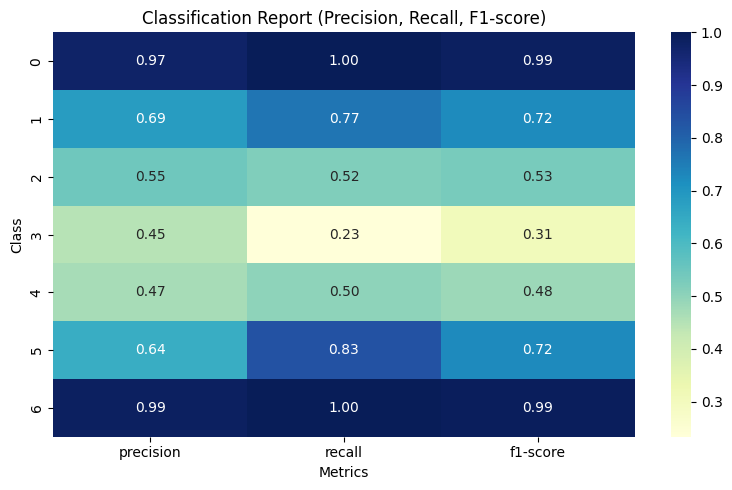

In [27]:
from sklearn.metrics import classification_report
import seaborn as sns
import pandas as pd

# === Classification Report as DataFrame ===
report_dict = classification_report(y_true, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

# Remove 'accuracy', 'macro avg', and 'weighted avg' rows (optional)
metrics_df = report_df.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')

# === Visualize as Heatmap ===
plt.figure(figsize=(8, 5))
sns.heatmap(metrics_df.iloc[:, :3], annot=True, cmap='YlGnBu', fmt=".2f")
plt.title("Classification Report (Precision, Recall, F1-score)")
plt.ylabel("Class")
plt.xlabel("Metrics")
plt.tight_layout()
plt.show()


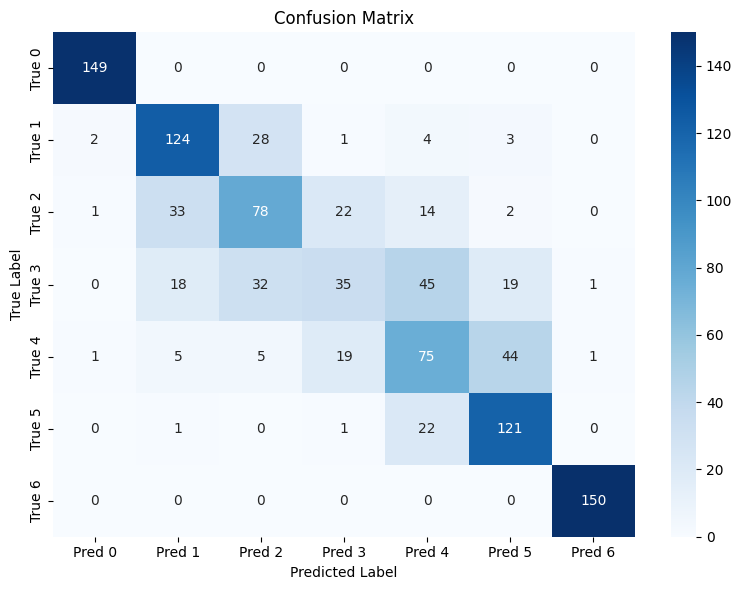

In [28]:
import seaborn as sns

# === Confusion Matrix ===
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f"Pred {i}" for i in range(y_train.shape[1])],
            yticklabels=[f"True {i}" for i in range(y_train.shape[1])])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


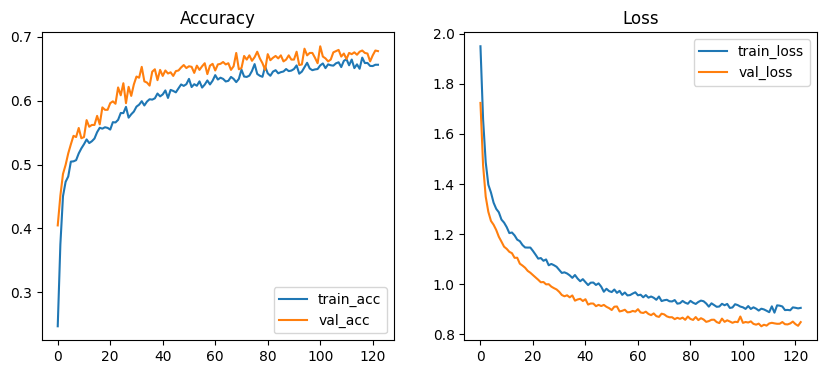

In [29]:



# === Plot training ===
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend(); plt.title('Accuracy')
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend(); plt.title('Loss')
plt.savefig("model3_training_curves.png")
plt.show()


In [30]:
# === Model Architecture (4 Hidden Layers, ReLU) ===
model4 = Sequential([
    Dense(96, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(96, activation='relu'),
    Dense(96, activation='relu'),
    Dense(96, activation='relu'),
    Dense(y_train.shape[1], activation='softmax')
])


c:\Users\aaaxx\miniconda3\envs\AttendanceSystem33\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
# === Compile Model ===
model4.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
# === Callbacks ===
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint = ModelCheckpoint('model_4.h5', monitor='val_accuracy', save_best_only=True)


In [33]:
# === Train Model ===
history = model4.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/100
73/77 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3221 - loss: 1.7657

77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3281 - loss: 1.7514 - val_accuracy: 0.4957 - val_loss: 1.2085
Epoch 2/100
74/77 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5276 - loss: 1.1419

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5287 - loss: 1.1397 - val_accuracy: 0.5403 - val_loss: 1.0494
Epoch 3/100
63/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5924 - loss: 0.9918

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5949 - loss: 0.9877 - val_accuracy: 0.5934 - val_loss: 0.9647
Epoch 4/100
70/77 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6324 - loss: 0.8955

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6323 - loss: 0.8948 - val_accuracy: 0.6114 - val_loss: 0.9397
Epoch 5/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6565 - loss: 0.8383

...

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8570 - loss: 0.3577 - val_accuracy: 0.7791 - val_loss: 0.5932
Epoch 28/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8566 - loss: 0.3668 - val_accuracy: 0.7659 - val_loss: 0.5975
Epoch 29/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8575 - loss: 0.3561 - val_accuracy: 0.7735 - val_loss: 0.6144
Epoch 30/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8664 - loss: 0.3424 - val_accuracy: 0.7773 - val_loss: 0.5675
Epoch 31/100
69/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8675 - loss: 0.3542

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8670 - loss: 0.3531 - val_accuracy: 0.7915 - val_loss: 0.5812
Epoch 32/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8727 - loss: 0.3241 - val_accuracy: 0.7858 - val_loss: 0.5668
Epoch 33/100
52/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8907 - loss: 0.2868

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8876 - loss: 0.2918 - val_accuracy: 0.7924 - val_loss: 0.5912
Epoch 34/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8747 - loss: 0.3006 - val_accuracy: 0.7915 - val_loss: 0.5750
Epoch 35/100
69/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8852 - loss: 0.2944

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8844 - loss: 0.2957 - val_accuracy: 0.7981 - val_loss: 0.5726
Epoch 36/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8887 - loss: 0.2874 - val_accuracy: 0.7697 - val_loss: 0.6080
Epoch 37/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8876 - loss: 0.2833 - val_accuracy: 0.7924 - val_loss: 0.5708
Epoch 38/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8905 - loss: 0.2879 - val_accuracy: 0.7867 - val_loss: 0.5860
Epoch 39/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8966 - loss: 0.2730 - val_accuracy: 0.7962 - val_loss: 0.5853
Epoch 40/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9007 - loss: 0.2548 - val_accuracy: 0.7915 - val_loss: 0.6048
Epoch 41/100
76/77 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8950 - loss: 0.2675

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8948 - loss: 0.2676 - val_accuracy: 0.7991 - val_loss: 0.6162
Epoch 42/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9000 - loss: 0.2519 - val_accuracy: 0.7687 - val_loss: 0.7243


In [40]:
model4.save("wine_model_fc4_adam_final.h5")

In [34]:
# === Save training history ===
with open("training_history_wine_fc4_adam.json", "w") as f:
    json.dump(history.history, f)


In [35]:
# === Evaluate ===
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")


33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7852 - loss: 0.6442
Test Accuracy: 0.7907


In [36]:
# === Predictions and Metrics ===
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


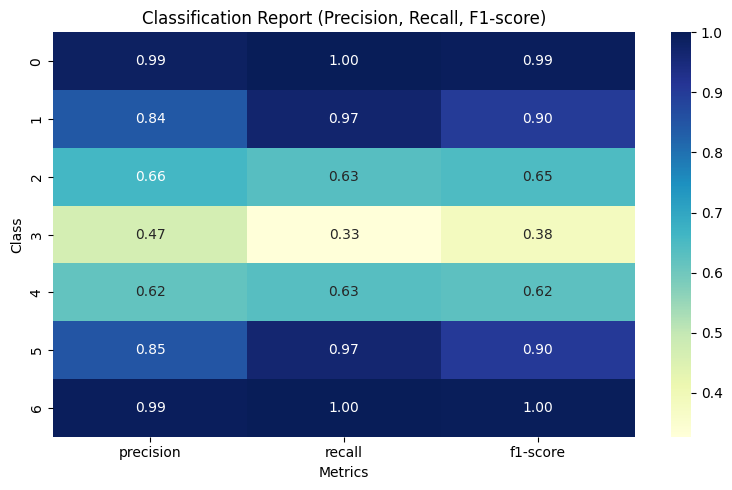

In [37]:
from sklearn.metrics import classification_report
import seaborn as sns
import pandas as pd

# === Classification Report as DataFrame ===
report_dict = classification_report(y_true, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

# Remove 'accuracy', 'macro avg', and 'weighted avg' rows (optional)
metrics_df = report_df.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')

# === Visualize as Heatmap ===
plt.figure(figsize=(8, 5))
sns.heatmap(metrics_df.iloc[:, :3], annot=True, cmap='YlGnBu', fmt=".2f")
plt.title("Classification Report (Precision, Recall, F1-score)")
plt.ylabel("Class")
plt.xlabel("Metrics")
plt.tight_layout()
plt.show()


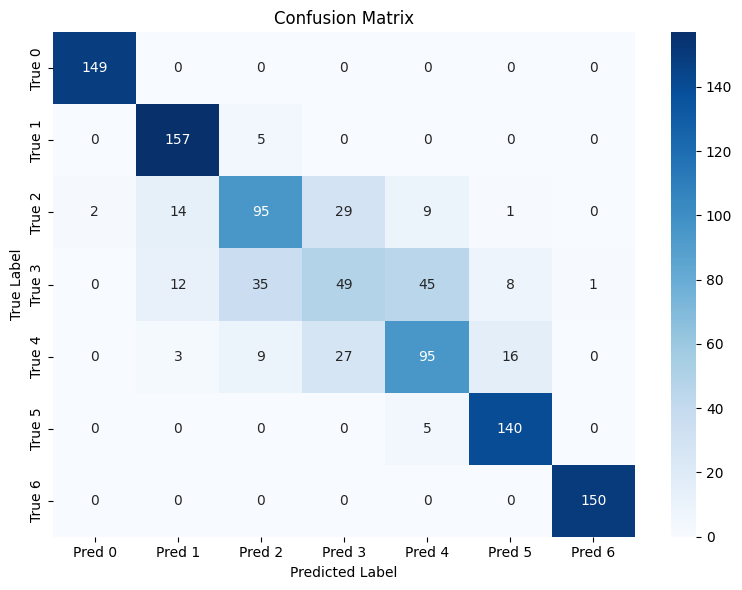

In [38]:
import seaborn as sns

# === Confusion Matrix ===
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f"Pred {i}" for i in range(y_train.shape[1])],
            yticklabels=[f"True {i}" for i in range(y_train.shape[1])])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


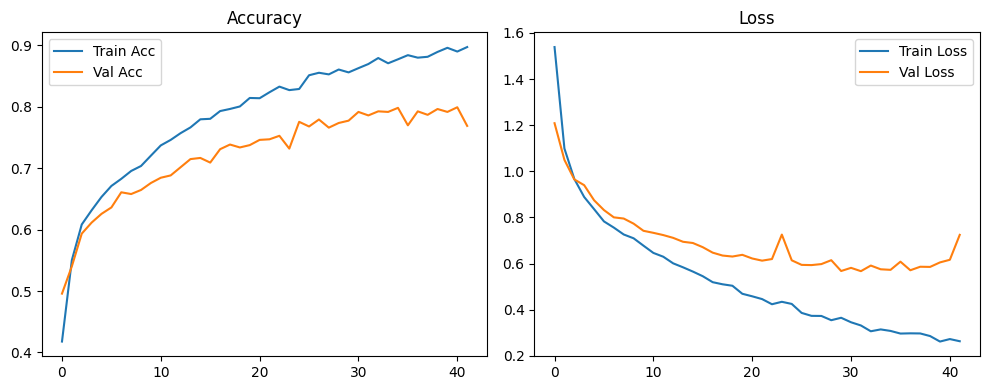

In [39]:

# === Plot training curves ===
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()
